In [1]:
import pandas as pd
import feature_engineering_helper as hf
import pickle


In [2]:

### change this to 1 for quick test, 0 for full run
quick_test = 0
### change this to 1 for quick test, 0 for full run


if quick_test == 1:
    n_features_to_select=40
    step=50
    print("Quick test mode")
else:
    n_features_to_select=1
    step=5
    print("Full run mode")



Full run mode


In [3]:
data_prefix = '../0_data/processed_data/'
figure_prefix = '../Figures/'
label = 'MP_label'
non_feature_cols = ['SMILES', 'MP', 'Type'] + [label]
model_lists = ['LGB']
data_types = ['L', 'H', 'All']


if quick_test == 1:
    df_all_feature = pd.read_parquet(data_prefix + 'data_with_all_features_scaled.parquet').head(500)
else:
    df_all_feature = pd.read_parquet(data_prefix + 'data_with_all_features.parquet')

df_all_feature

,MACCS_0,MACCS_1,MACCS_10,MACCS_100,MACCS_101,MACCS_102,MACCS_103,MACCS_104,MACCS_105,MACCS_106,...,RDKit_fr_term_acetylene,RDKit_fr_tetrazole,RDKit_fr_thiazole,RDKit_fr_thiocyan,RDKit_fr_thiophene,RDKit_fr_unbrch_alkane,RDKit_fr_urea,RDKit_qed,SMILES,Type
0,0,0,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0.399047,COc1ccc(cc1)C1(C)CCc2c(-c3c1cc(o3)C)c1c(o2)ccc...,Train
1,0,0,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0.497846,C[C@H]1[C@@H]2CC[C@@H]3[C@](C1=O)(C2)C(=O)OC[C...,Train
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.667560,Cc1cc(Br)c(cc1Br)C,Train
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.669548,OC(=O)c1ccc(c(c1)F)C,Train
4,0,0,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0.703933,OC(=O)C1CC(=O)c2c1cccc2,Train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17215,0,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0.438791,CN(CCNCc1cc(ccc1O)[N+](=O)[O-])C,Test
17216,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.490747,C[Si](C#Cc1ccc(cc1)C#C[Si](C)(C)C)(C)C,Test
17217,0,0,0,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0.579542,Brc1ccc(c(c1)C(F)(F)F)[N+](=O)[O-],Test
17218,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.701361,OC(=O)C(C(=O)O)Cc1ccccc1,Test


In [4]:
def feature_engineering_workflow(model_type, df):

    data = df.copy()
    tolerance = 0.01

    # Extract all feature columns
    all_feature_cols = data.drop(columns=non_feature_cols).columns.tolist()
    print(f"Total number of features: {len(all_feature_cols)}")
    print()

    # Reduce features by variance threshold
    variance_threshold = 0.01
    print(f'Variance threshold feature selection: variance_threshold={variance_threshold}')
    df_X_variance = hf.reduce_features_by_variance(data[all_feature_cols], variance_threshold=variance_threshold)
    print()


    print(f'RFE feature selection: model={model_type}, tolerance={tolerance}, n_features_to_select={n_features_to_select}, step={step}')
    # Reduce features by RFE
    RFE_results = hf.reduce_features_by_RFE(df_X_variance, data['MP'], model = model_type, tolerance = tolerance, n_features_to_select=n_features_to_select, step=step, metric='rmse', cv_strategy=None)
    print()

    # Plot RFE results
    hf.RFE_plot(RFE_results, tolerance , model_type,save_path = figure_prefix + f'RFE_plot_{model_type}.png')


    df_X_RFE = df_X_variance[RFE_results['best_features']]


    return df_X_variance, RFE_results, df_X_RFE

Running feature engineering workflow with LGB model on L data
Number of samples: 11439, Number of features: 388
Total number of features: 384

Variance threshold feature selection: variance_threshold=0.01
Original features: 384
Removed features: 50
Remaining features: 334

RFE feature selection: model=LGB, tolerance=0.01, n_features_to_select=1, step=5


RFE Feature Selection:   1%|▏         | 1/67 iteration

Iteration 0/67 | Features: 329 | RMSE: 34.0117 ± 1.3106 | Removed: [MACCS_19, MACCS_24, MACCS_25, MACCS_87, RDKit_fr_oxime]


RFE Feature Selection:  16%|█▋        | 11/67 iteration

Iteration 10/67 | Features: 279 | RMSE: 33.9656 ± 1.2122 | Removed: [MACCS_141, MACCS_33, MACCS_37, RDKit_fr_imide, RDKit_fr_nitro_arom_nonortho]


...

Iteration 50/67 | Features: 79 | RMSE: 34.2573 ± 1.1283 | Removed: [MACCS_127, MACCS_142, RDKit_Chi1, RDKit_Chi2n, RDKit_PEOE_VSA2]


RFE Feature Selection:  91%|█████████ | 61/67 iteration

Iteration 60/67 | Features: 29 | RMSE: 35.0080 ± 1.0644 | Removed: [RDKit_BCUT2D_CHGLO, RDKit_FractionCSP3, RDKit_HeavyAtomMolWt, RDKit_RingCount, RDKit_VSA_EState5]


RFE Feature Selection: 100%|██████████| 67/67 iteration



Global best RMSE: 33.8411
Threshold (1.0% tolerance): 34.1795

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 89
  Selected RMSE: 34.1129
  Best features (Top 5): ['RDKit_TPSA', 'RDKit_FpDensityMorgan3', 'RDKit_BCUT2D_MRHI', 'RDKit_SMR_VSA10', 'RDKit_VSA_EState4']



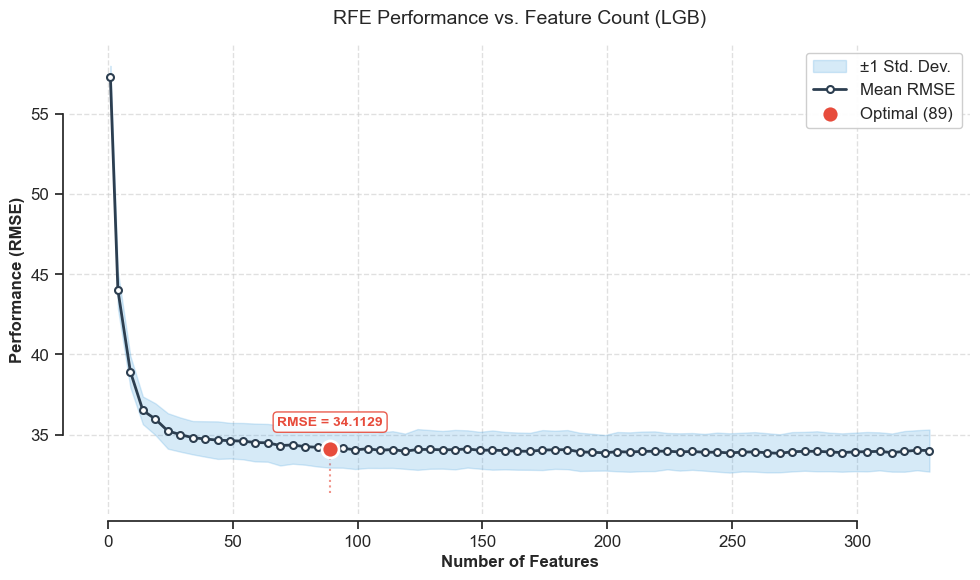

  Optimal Feature Set: 89 features
  Best RMSE: 34.1129

Running feature engineering workflow with LGB model on H data
Number of samples: 615, Number of features: 388
Total number of features: 384

Variance threshold feature selection: variance_threshold=0.01
Original features: 384
Removed features: 64
Remaining features: 320

RFE feature selection: model=LGB, tolerance=0.01, n_features_to_select=1, step=5


RFE Feature Selection:   2%|▏         | 1/64 iteration

Iteration 0/64 | Features: 315 | RMSE: 28.5782 ± 6.0379 | Removed: [MACCS_100, MACCS_90, MACCS_91, MACCS_93, MACCS_94]


RFE Feature Selection:  17%|█▋        | 11/64 iteration

Iteration 10/64 | Features: 265 | RMSE: 28.4779 ± 6.0457 | Removed: [MACCS_51, MACCS_52, MACCS_53, MACCS_55, RDKit_fr_hdrzone]


...

Iteration 50/64 | Features: 65 | RMSE: 28.3475 ± 5.7469 | Removed: [MACCS_163, RDKit_Chi0v, RDKit_EState_VSA1, RDKit_ExactMolWt, RDKit_PEOE_VSA11]


RFE Feature Selection:  95%|█████████▌| 61/64 iteration

Iteration 60/64 | Features: 15 | RMSE: 28.4302 ± 5.5650 | Removed: [RDKit_FpDensityMorgan1, RDKit_FpDensityMorgan2, RDKit_MinEStateIndex, RDKit_MolLogP, RDKit_PEOE_VSA7]


RFE Feature Selection: 100%|██████████| 64/64 iteration



Global best RMSE: 28.0912
Threshold (1.0% tolerance): 28.3722

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 55
  Selected RMSE: 28.2607
  Best features (Top 5): ['RDKit_qed', 'RDKit_FpDensityMorgan3', 'RDKit_SMR_VSA10', 'RDKit_FpDensityMorgan2', 'RDKit_Phi']



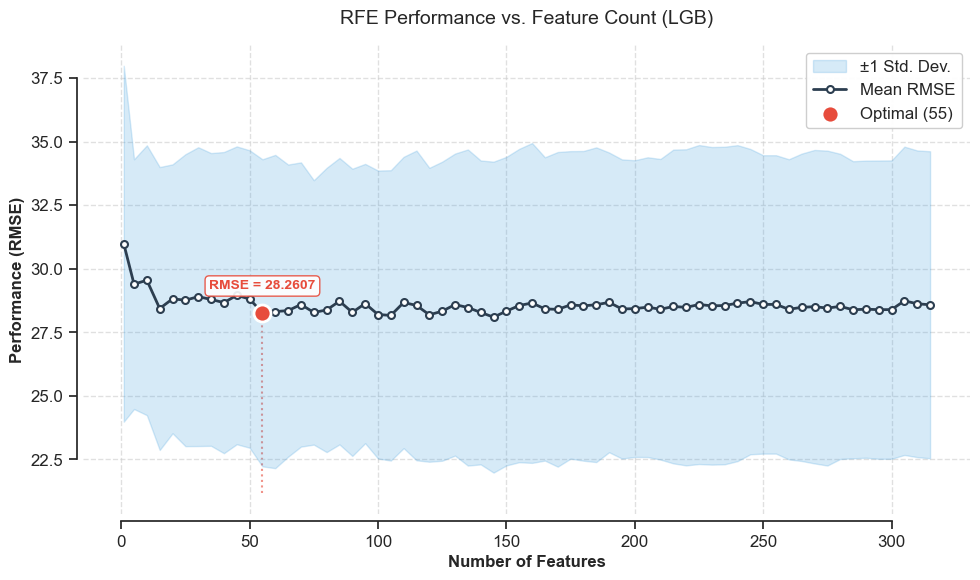

  Optimal Feature Set: 55 features
  Best RMSE: 28.2607

Running feature engineering workflow with LGB model on All data
Number of samples: 12054, Number of features: 388
Total number of features: 384

Variance threshold feature selection: variance_threshold=0.01
Original features: 384
Removed features: 51
Remaining features: 333

RFE feature selection: model=LGB, tolerance=0.01, n_features_to_select=1, step=5


RFE Feature Selection:   1%|▏         | 1/67 iteration

Iteration 0/67 | Features: 328 | RMSE: 37.3022 ± 0.7879 | Removed: [MACCS_148, MACCS_19, MACCS_71, MACCS_75, MACCS_76]


RFE Feature Selection:  16%|█▋        | 11/67 iteration

Iteration 10/67 | Features: 278 | RMSE: 37.3812 ± 0.9122 | Removed: [MACCS_123, RDKit_fr_Ndealkylation2, RDKit_fr_aniline, RDKit_fr_imide, RDKit_fr_thiophene]


...

Iteration 50/67 | Features: 78 | RMSE: 37.6905 ± 0.9104 | Removed: [MACCS_131, MACCS_89, RDKit_Chi0, RDKit_EState_VSA4, RDKit_fr_imidazole]


RFE Feature Selection:  91%|█████████ | 61/67 iteration

Iteration 60/67 | Features: 28 | RMSE: 38.6944 ± 1.0649 | Removed: [RDKit_AvgIpc, RDKit_BalabanJ, RDKit_RingCount, RDKit_SMR_VSA3, RDKit_SMR_VSA5]


RFE Feature Selection: 100%|██████████| 67/67 iteration



Global best RMSE: 37.2762
Threshold (1.0% tolerance): 37.6490

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 83
  Selected RMSE: 37.6197
  Best features (Top 5): ['RDKit_FpDensityMorgan3', 'RDKit_TPSA', 'RDKit_NumRotatableBonds', 'RDKit_SMR_VSA10', 'RDKit_BCUT2D_LOGPHI']



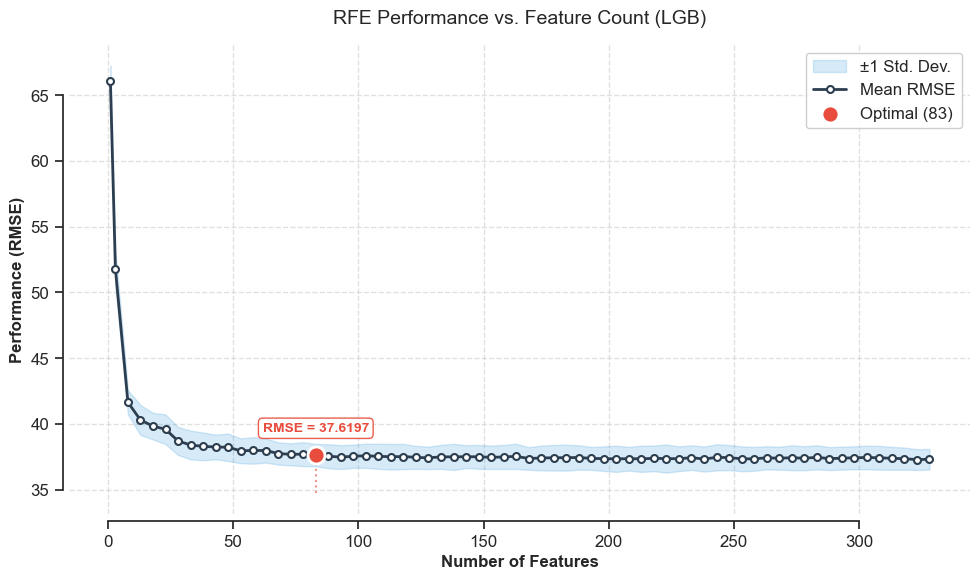

  Optimal Feature Set: 83 features
  Best RMSE: 37.6197



In [5]:
feature_engineering_dict = {}

for model_type in model_lists:

    for data_type in data_types:

        data_train = df_all_feature[df_all_feature['Type'] == 'Train']
        if data_type == 'L':
            data_with_features_train = data_train[data_train[label] == 'L']
        elif data_type == 'H':
            data_with_features_train = data_train[data_train[label] == 'H']
        else:
            data_with_features_train = data_train
        

        print(f"Running feature engineering workflow with {model_type} model on {data_type} data")
        print(f"Number of samples: {data_with_features_train.shape[0]}, Number of features: {data_with_features_train.shape[1]}")
        
        df_X_variance, RFE_results, df_X_RFE = feature_engineering_workflow(model_type, data_with_features_train)
        feature_engineering_dict[(model_type, data_type)] = RFE_results
        print()

# pickle save the feature_engineering_dict
with open('feature_engineering_dict.pkl', 'wb') as f:
    pickle.dump(feature_engineering_dict, f)

# Get the dataset

In [6]:
data_with_features = pd.read_parquet(data_prefix + 'data_with_all_features.parquet')
data_with_features_scaled = pd.read_parquet(data_prefix + 'data_with_all_features_scaled.parquet')

In [7]:
# load the feature_engineering_dict
with open('feature_engineering_dict.pkl', 'rb') as f:
    feature_engineering_dict = pickle.load(f)

In [8]:

for model_type in model_lists:
    for data_type in data_types:

        best_features = feature_engineering_dict[(model_type, data_type)]['best_features']
        print(f"Best features for {model_type} model - {data_type} data ({len(best_features)} features):")
        print(best_features)
        print()

        data_selected_features = data_with_features[non_feature_cols + best_features]
        data_selected_features_scaled = data_with_features_scaled[non_feature_cols + best_features]

        data_selected_features.to_parquet(data_prefix + f'data_with_selected_features_{model_type}_{data_type}.parquet')
        data_selected_features_scaled.to_parquet(data_prefix + f'data_with_selected_features_{model_type}_{data_type}_scaled.parquet')



Best features for LGB model - L data (89 features):
['RDKit_TPSA', 'RDKit_FpDensityMorgan3', 'RDKit_BCUT2D_MRHI', 'RDKit_SMR_VSA10', 'RDKit_VSA_EState4', 'RDKit_NumRotatableBonds', 'RDKit_BertzCT', 'RDKit_BCUT2D_MWLOW', 'RDKit_MinPartialCharge', 'RDKit_MaxPartialCharge', 'RDKit_BCUT2D_MRLOW', 'RDKit_VSA_EState3', 'RDKit_qed', 'RDKit_Kappa3', 'RDKit_BCUT2D_LOGPHI', 'RDKit_RingCount', 'RDKit_PEOE_VSA7', 'RDKit_FractionCSP3', 'RDKit_BCUT2D_LOGPLOW', 'RDKit_BalabanJ', 'RDKit_MaxAbsPartialCharge', 'RDKit_MinAbsPartialCharge', 'RDKit_VSA_EState2', 'RDKit_FpDensityMorgan2', 'RDKit_VSA_EState1', 'RDKit_VSA_EState6', 'RDKit_PEOE_VSA8', 'RDKit_SlogP_VSA2', 'RDKit_SPS', 'RDKit_SlogP_VSA8', 'RDKit_VSA_EState5', 'RDKit_MinAbsEStateIndex', 'RDKit_VSA_EState9', 'RDKit_BCUT2D_CHGLO', 'RDKit_HallKierAlpha', 'RDKit_SlogP_VSA1', 'RDKit_SMR_VSA5', 'RDKit_PEOE_VSA10', 'RDKit_EState_VSA8', 'RDKit_BCUT2D_MWHI', 'RDKit_MinEStateIndex', 'RDKit_VSA_EState7', 'RDKit_BCUT2D_CHGHI', 'RDKit_SlogP_VSA4', 'RDKit_PEOE